# Customer Purchase Prediction using Machine learning
**Objective:Predict whether a customer will purchase a product based on age and salary.**

**import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import joblib

**Load And Check Data**

In [2]:

df=pd.read_csv("dataa.csv")
print(df.head())
print(df.shape)
print(df.info())

    Age  EstimatedSalary  Purchased
0  18.0          15000.0        0.0
1  19.0          18000.0        0.0
2  20.0          20000.0        0.0
3  21.0          22000.0        0.0
4  22.0          25000.0        0.0
(215, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              213 non-null    float64
 1   EstimatedSalary  212 non-null    float64
 2   Purchased        213 non-null    float64
dtypes: float64(3)
memory usage: 5.2 KB
None


**Check missing values**

In [3]:
print(df.isnull().sum())

Age                2
EstimatedSalary    3
Purchased          2
dtype: int64


**Handled missing values using data cleaning techniques**

In [4]:
df=df.dropna()
df=df.drop_duplicates()
print(df.isnull().sum())

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


***Prepare*** **Data**

In [5]:
X=df[['Age','EstimatedSalary']]
Y=df['Purchased']

**Statistics**

In [6]:
print(df.describe())

              Age  EstimatedSalary   Purchased
count  208.000000       208.000000  208.000000
mean    39.163462     69798.076923    0.639423
std     12.428043     31139.046060    0.481326
min     18.000000     15000.000000    0.000000
25%     28.750000     43000.000000    0.000000
50%     39.000000     70000.000000    1.000000
75%     50.000000     96250.000000    1.000000
max     60.000000    124000.000000    1.000000


 **Split Data**

In [7]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.2,random_state=42)

**Train And Evaluate mode**

In [8]:
scaler=StandardScaler()
Xtrain_scaled=scaler.fit_transform(Xtrain)
Xtest_scaled=scaler.transform(Xtest)

model = LogisticRegression()
model.fit(Xtrain_scaled, Ytrain)
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
y_pred=model.predict(Xtest_scaled)
accuracy=accuracy_score(Ytest,y_pred)
print("Accuracy",accuracy)

Accuracy 1.0


**Model Score**

In [9]:
print("Train score:",model.score(Xtrain_scaled,Ytrain))
print("Test score:",model.score(Xtest,Ytest))
print(df.corr())

Train score: 1.0
Test score: 0.6904761904761905
                      Age  EstimatedSalary  Purchased
Age              1.000000         0.998956   0.830405
EstimatedSalary  0.998956         1.000000   0.830245
Purchased        0.830405         0.830245   1.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


# Plotting

**Predicted Vs Actual**

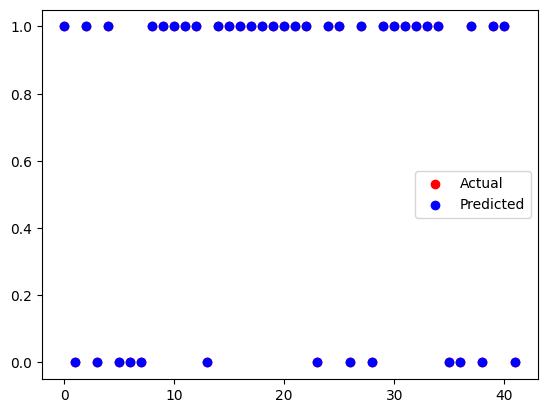

In [10]:
plt.scatter(range(len(Ytest)),Ytest,color='red',label='Actual')
plt.scatter(range(len(Ytest)),y_pred,color='blue',label='Predicted')
plt.legend()
plt.show()

**Purchased Vs Age**

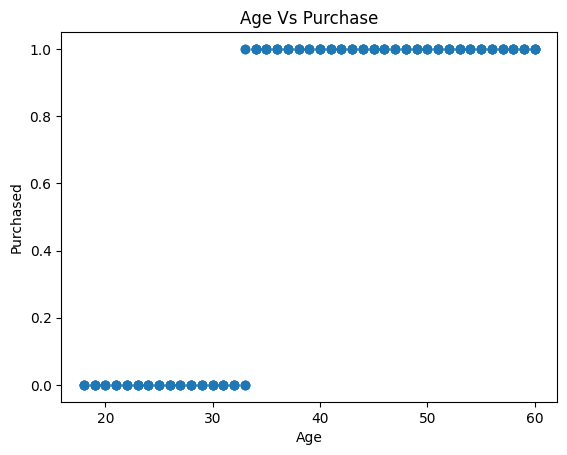

In [11]:
plt.scatter(df['Age'],df['Purchased'])
plt.xlabel("Age")
plt.ylabel("Purchased")
plt.title("Age Vs Purchase")
plt.show()

# Salary Vs Purchase

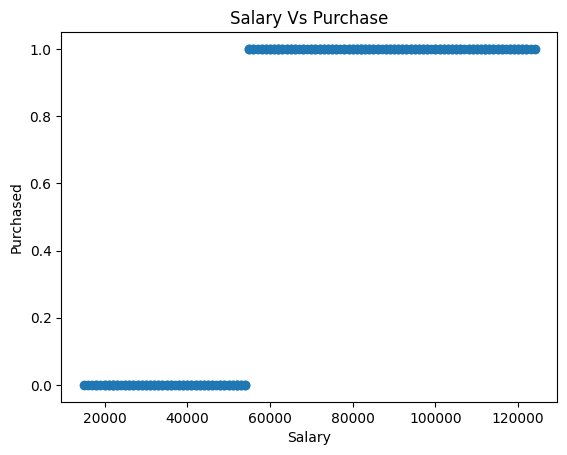

In [12]:
plt.figure()
plt.scatter(df['EstimatedSalary'],df['Purchased'])
plt.title("Salary Vs Purchase")
plt.xlabel("Salary")
plt.ylabel("Purchased")
plt.show()

**Test Multiple Values**

In [13]:
tests=[[20,2000],[40,9000],[55,120000],[30,50000]]
for t in tests:
    test_df = pd.DataFrame([t], columns=['Age', 'EstimatedSalary'])
    test_scaled=scaler.transform(test_df)
    prediction=model.predict(test_scaled)
    print(t,"=>",prediction)

[20, 2000] => [0.]
[40, 9000] => [0.]
[55, 120000] => [1.]
[30, 50000] => [0.]
